In [8]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (accuracy_score, f1_score, precision_score, 
                             recall_score, cohen_kappa_score, matthews_corrcoef)

In [9]:
# --- PHASE 1: HYPERPARAMETER CONFIGURATION & REPRODUCIBILITY ---
# Setting global seeds ensures the reproducibility of the stochastic weight initialization.
PARAMS = {
    "VOCAB_SIZE": 3000,
    "HIDDEN_DIM": 64,
    "EPOCHS": 100,
    "LR": 1e-3,  # 0.001: Optimized for convergence stability in neural architectures
    "SEED": 42
}

torch.manual_seed(PARAMS["SEED"])
np.random.seed(PARAMS["SEED"])

In [10]:
# --- PHASE 2: DATA ENGINEERING & TF-IDF VECTORIZATION ---
# Preprocessing the SMS Spam Collection dataset.
df = pd.read_csv('spam.csv', encoding='latin-1')[['v1', 'v2']]
df.columns = ['label', 'text']
df['label'] = df['label'].map({'ham': 0, 'spam': 1})

# Feature extraction: Converting raw text into numerical TF-IDF feature vectors.
tfidf = TfidfVectorizer(max_features=PARAMS["VOCAB_SIZE"], stop_words='english')
X = tfidf.fit_transform(df['text']).toarray()
y = df['label'].values

# Data Partitioning: 70% Training, 15% Validation (for hyperparameter tuning), and 15% Testing.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=PARAMS["SEED"])
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.1764, random_state=PARAMS["SEED"])

# Tensor Conversion: Transferring data to PyTorch FloatTensors for gradient-based optimization.
X_train_t = torch.FloatTensor(X_train)
y_train_t = torch.FloatTensor(y_train).view(-1, 1)
X_val_t = torch.FloatTensor(X_val)
y_val_t = torch.FloatTensor(y_val).view(-1, 1)
X_test_t = torch.FloatTensor(X_test)

In [11]:
# --- PHASE 3: NEURAL NETWORK ARCHITECTURES ---
# Defining Baseline Logistic Regression and Multi-Layer Perceptron (MLP) models.
class LogisticRegressionModel(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.linear = nn.Linear(input_dim, 1)
    def forward(self, x):
        return torch.sigmoid(self.linear(x))

class MLPModel(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, PARAMS["HIDDEN_DIM"]),
            nn.ReLU(),
            nn.Linear(PARAMS["HIDDEN_DIM"], 1),
            nn.Sigmoid()
        )
    def forward(self, x):
        return self.net(x)

In [12]:
# --- PHASE 4: LOSS FUNCTION REGISTRY ---
# A diverse set of loss functions representing probabilistic, geometric, and robust paradigms.
loss_functions = {
    "BCE": nn.BCELoss(),           # Standard Binary Cross Entropy
    "MSE": nn.MSELoss(),           # Mean Squared Error (Quadratic Loss)
    "MAE": nn.L1Loss(),            # Mean Absolute Error (Linear Loss)
    "Huber": nn.SmoothL1Loss(),    # Smooth L1 (Robustness to outliers)
    "Margin": nn.SoftMarginLoss()  # Margin-based objective for linear separation
}


In [13]:
# --- PHASE 5: EXPERIMENTAL EXECUTION LOOP ---
results_history = {}
performance_metrics = []

for model_type in ["LR", "MLP"]:
    for loss_name, criterion in loss_functions.items():
        exp_name = f"{model_type}_{loss_name}"
        print(f"Training Model Variant: {exp_name}...")
        
        model = LogisticRegressionModel(PARAMS["VOCAB_SIZE"]) if model_type == "LR" else MLPModel(PARAMS["VOCAB_SIZE"])
        optimizer = optim.Adam(model.parameters(), lr=PARAMS["LR"])
        
        train_accs, val_accs = [], []
        
        for epoch in range(PARAMS["EPOCHS"]):
            model.train()
            optimizer.zero_grad()
            outputs = model(X_train_t)
            
            # Special handling for SoftMarginLoss: Targets transformed to {-1, 1}
            if isinstance(criterion, nn.SoftMarginLoss):
                target = y_train_t.clone().apply_(lambda x: 1 if x == 1 else -1)
                loss = criterion(outputs, target)
            else:
                loss = criterion(outputs, y_train_t)
                
            loss.backward()
            optimizer.step()
            
            # Epoch-wise evaluation for generalization monitoring (Overfitting Analysis)
            model.eval()
            with torch.no_grad():
                t_pred = (model(X_train_t) > 0.5).float().numpy()
                v_pred = (model(X_val_t) > 0.5).float().numpy()
                train_accs.append(accuracy_score(y_train, t_pred))
                val_accs.append(accuracy_score(y_val, v_pred))
        
        results_history[exp_name] = {"train": train_accs, "val": val_accs}
        
        # --- PHASE 6: EXTENDED STATISTICAL EVALUATION ---
        # Assessing the model on unseen test data using robust correlation metrics.
        with torch.no_grad():
            test_outputs = model(X_test_t)
            y_pred_test = (test_outputs > 0.5).float().numpy()
            
            performance_metrics.append({
                "Model_Loss": exp_name,
                "Accuracy": accuracy_score(y_test, y_pred_test),
                "Precision": precision_score(y_test, y_pred_test, zero_division=0),
                "Recall": recall_score(y_test, y_pred_test, zero_division=0),
                "F1-Score": f1_score(y_test, y_pred_test, zero_division=0),
                "MCC": matthews_corrcoef(y_test, y_pred_test),
                "Kappa": cohen_kappa_score(y_test, y_pred_test)
            })


Training Model Variant: LR_BCE...
Training Model Variant: LR_MSE...
Training Model Variant: LR_MAE...
Training Model Variant: LR_Huber...
Training Model Variant: LR_Margin...
Training Model Variant: MLP_BCE...
Training Model Variant: MLP_MSE...
Training Model Variant: MLP_MAE...
Training Model Variant: MLP_Huber...
Training Model Variant: MLP_Margin...


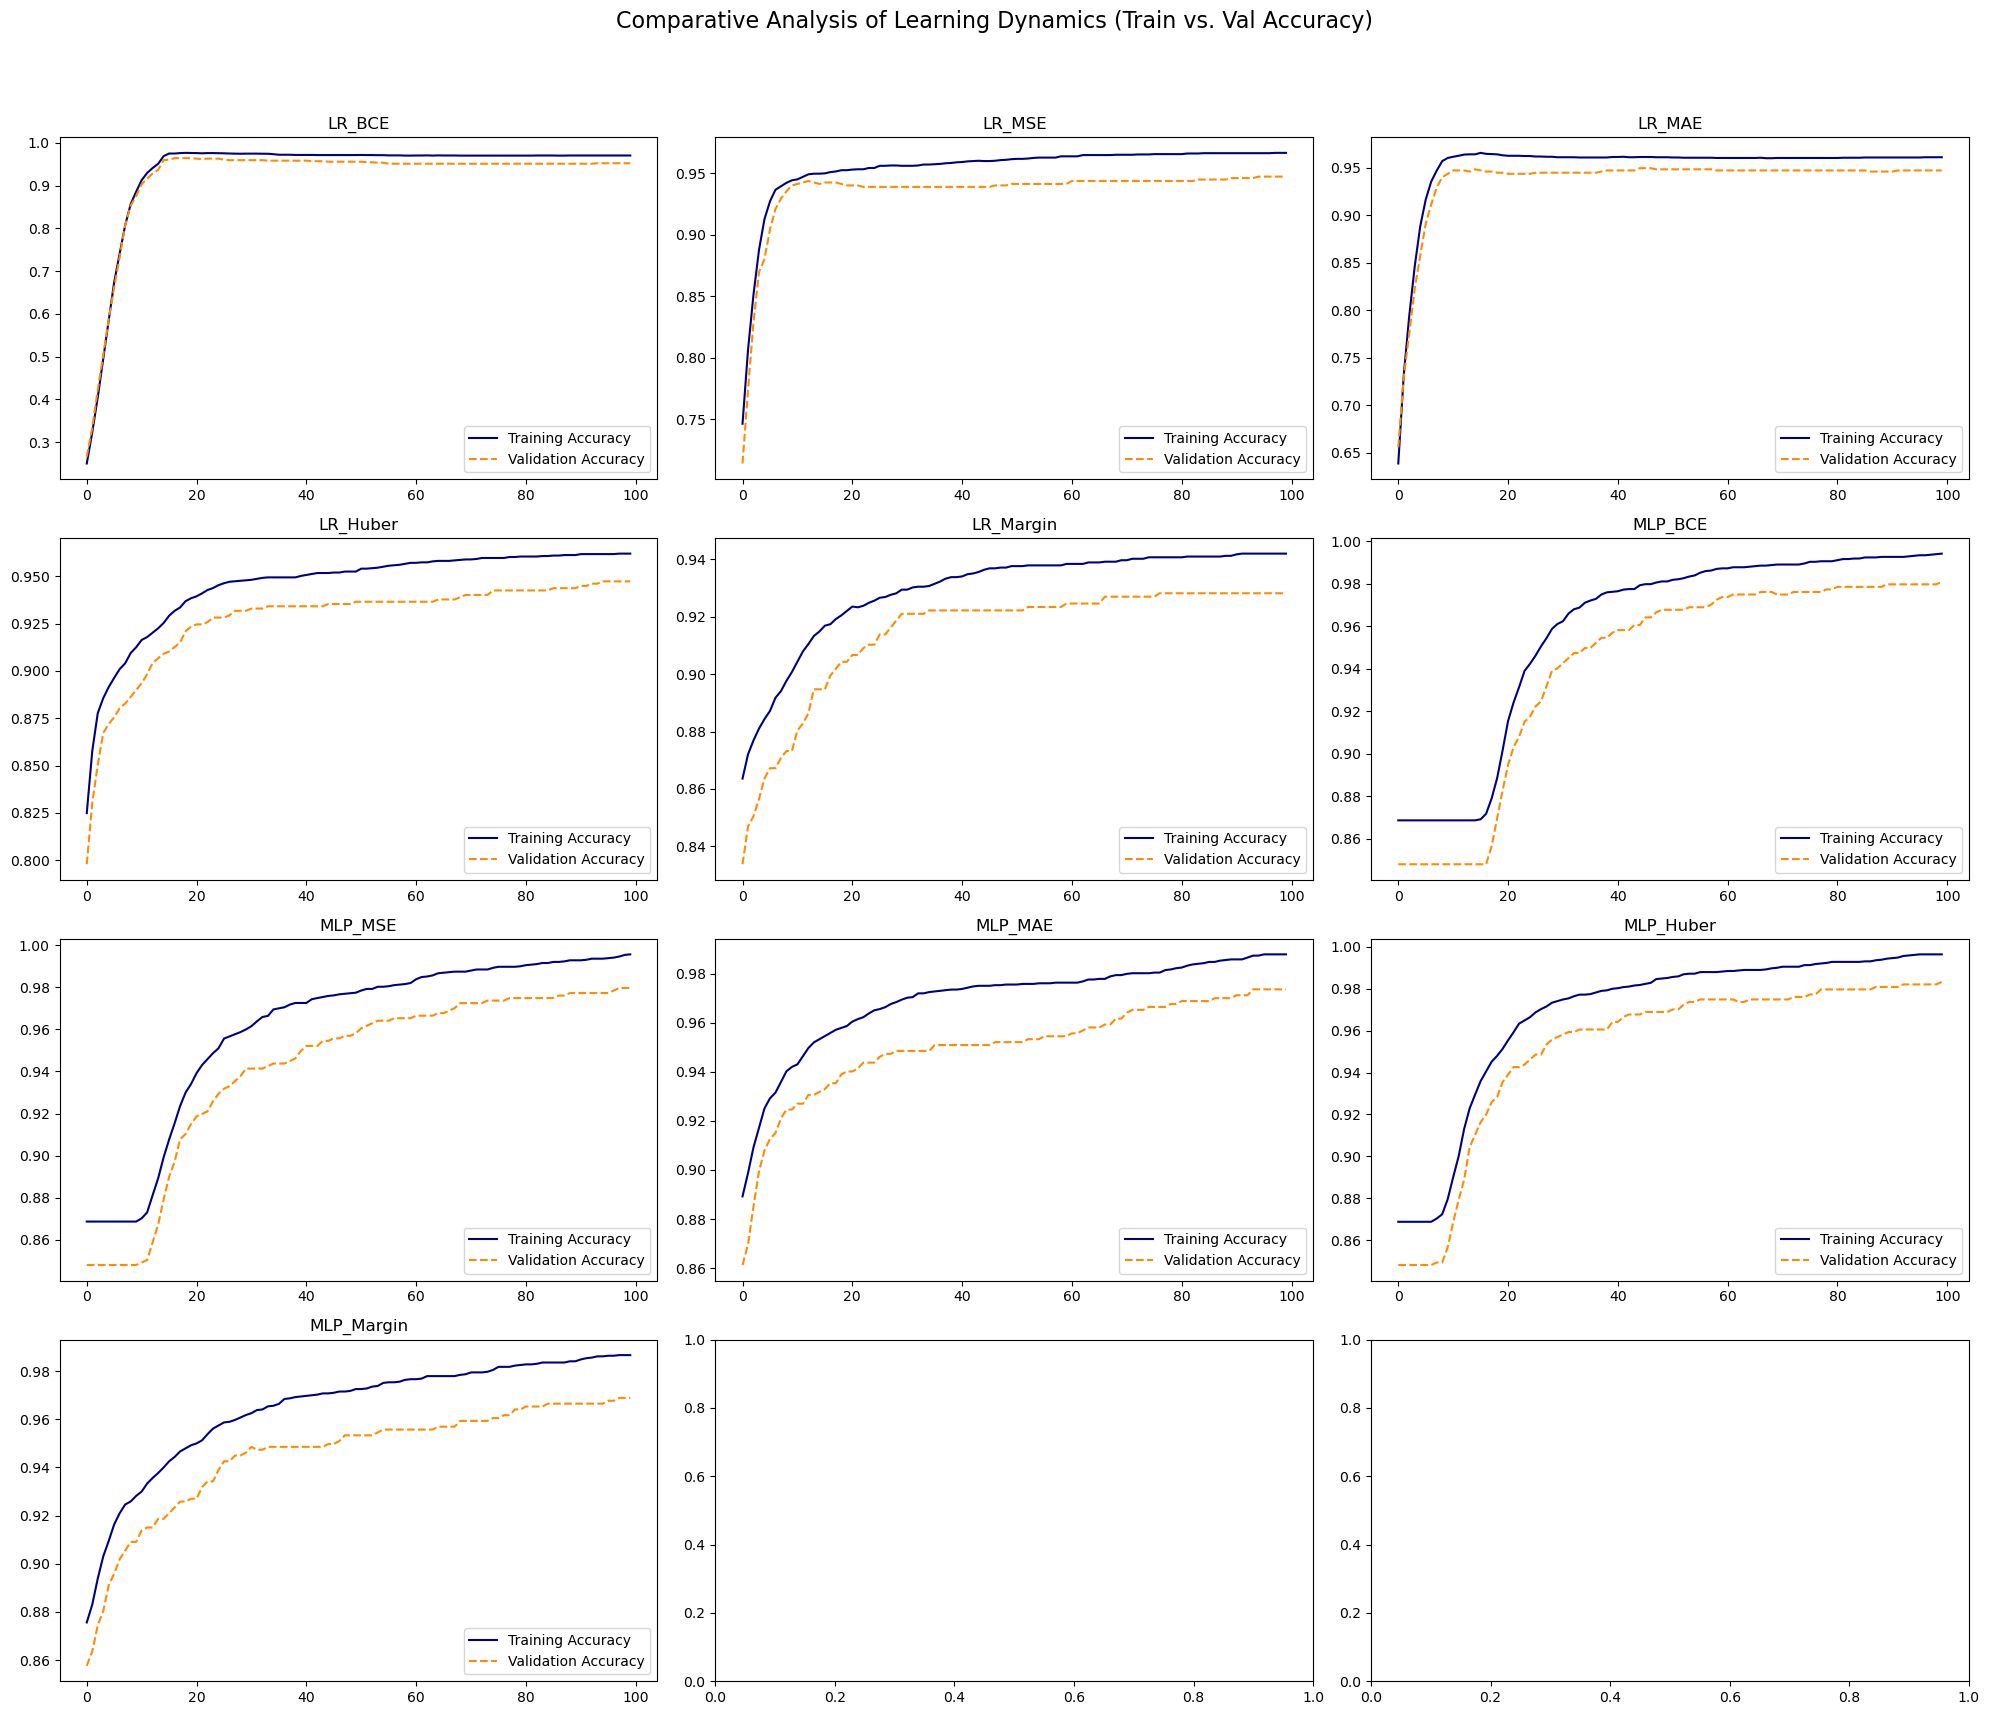

In [14]:
# --- PHASE 7: VISUAL ANALYTICS & TABULAR REPORTING ---
# Visualizing learning trajectories and reporting final metric matrices.
fig, axes = plt.subplots(4, 3, figsize=(20, 18))
axes = axes.ravel()
for i, (name, h) in enumerate(results_history.items()):
    axes[i].plot(h["train"], label='Training Accuracy', color='navy')
    axes[i].plot(h["val"], label='Validation Accuracy', linestyle='--', color='darkorange')
    axes[i].set_title(name, fontsize=12)
    axes[i].legend(loc='lower right')

plt.suptitle("Comparative Analysis of Learning Dynamics (Train vs. Val Accuracy)", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [15]:
print("\n" + "="*110)
print("SPAM DATASET")
print("="*110)
print(pd.DataFrame(performance_metrics).to_string(index=False))


SPAM DATASET
Model_Loss  Accuracy  Precision   Recall  F1-Score      MCC    Kappa
    LR_BCE  0.966507   0.976190 0.759259  0.854167 0.844005 0.835581
    LR_MSE  0.960526   0.974684 0.712963  0.823529 0.814341 0.801907
    LR_MAE  0.954545   0.948718 0.685185  0.795699 0.783803 0.770873
  LR_Huber  0.955742   0.986301 0.666667  0.795580 0.790436 0.771800
 LR_Margin  0.934211   0.981818 0.500000  0.662577 0.674599 0.630350
   MLP_BCE  0.980861   0.950980 0.898148  0.923810 0.913363 0.912876
   MLP_MSE  0.980861   0.950980 0.898148  0.923810 0.913363 0.912876
   MLP_MAE  0.977273   0.949495 0.870370  0.908213 0.896375 0.895271
 MLP_Huber  0.979665   0.941748 0.898148  0.919431 0.908137 0.907803
MLP_Margin  0.978469   0.959184 0.870370  0.912621 0.901758 0.900376
